# End-to-End Predictive Analytics Project: Telco Customer Churn

**Aptura Tech Solutions 1-Month Internship Program (Batch 02)**
**Week 03 Task Data Science**

**Objective:** Build a complete predictive analytics pipeline data collection, cleaning,
feature engineering, model training, hyperparameter tuning, evaluation, and business
insights and answer two applied ML systems-design questions.

---
### Table of Contents
1. [Dataset Selection & Justification](#1)
2. [Data Collection](#2)
3. [Exploratory Data Analysis](#3)
4. [Data Cleaning](#4)
5. [Feature Engineering](#5)
6. [Train/Test Split & Preprocessing Pipeline](#6)
7. [Model Training Baseline Comparison](#7)
8. [Hyperparameter Tuning](#8)
9. [Model Evaluation & Final Model Selection](#9)
10. [Business Insights](#10)
11. [Question 01 Overfitting: 99% Train vs 74% Test Accuracy](#11)
12. [Question 02 Scaling the Workflow to 50 Million Records](#12)
13. [Conclusion](#13)


## Setup

Import libraries and add the `src/` package (reusable, documented modules) to the path.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from data_processing import load_data, clean_data, get_feature_types
from feature_engineering import engineer_features, build_preprocessor
from model_training import get_candidate_models, get_param_grids, build_pipeline, tune_model
from evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curve, plot_feature_importance, get_feature_names

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42


<a id='1'></a>
## 1. Dataset Selection & Justification

**Dataset:** [Telco Customer Churn](https://github.com/IBM/telco-customer-churn-on-icp4d) (IBM sample dataset,
widely used in the Kaggle/UCI-style public ML community) 7,043 customer records from a
telecommunications company, 21 columns.

**Why this dataset:**
- **Real-world business relevance.** Customer churn prediction is one of the highest-ROI
  applications of predictive analytics acquiring a new customer typically costs 5-25x more
  than retaining an existing one, so even a modestly accurate model drives measurable business
  value.
- **Rich mixed feature types.** It contains numeric (tenure, charges), binary, and multi-category
  categorical features, which exercises the full feature-engineering and preprocessing pipeline
  (scaling, one-hot encoding, handling missing/blank values).
- **Realistic data quality issues.** `TotalCharges` is stored as a string with blank values for
  brand-new customers a good stand-in for the kind of messy data engineers meet in production.
- **Class imbalance (~26.5% churn).** Forces proper use of precision/recall/F1/ROC-AUC rather
  than accuracy alone a good teaching example for Question 01.
- **Suitable size for demonstrating overfitting.** Small-to-medium row count with many categorical
  levels makes it easy for a flexible model (e.g., an unconstrained decision tree) to memorize
  the training set, which is exactly the scenario Question 01 asks us to diagnose.


<a id='2'></a>
## 2. Data Collection

The raw CSV is loaded via a reusable `load_data()` function (see `src/data_processing.py`).
In production this step would instead pull from a data warehouse / CRM export on a schedule
see Question 02 for how this changes at 50M-record scale.

In [2]:
df_raw = load_data('../data/telco.csv')
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df_raw.describe(include='all').T.head(10)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<a id='3'></a>
## 3. Exploratory Data Analysis

Before cleaning, we inspect data quality issues and the target distribution.

In [5]:
# TotalCharges is object dtype - contains blank strings for tenure==0 customers
print("TotalCharges dtype:", df_raw['TotalCharges'].dtype)
blank_mask = df_raw['TotalCharges'].str.strip() == ''
print(f"Blank TotalCharges rows: {blank_mask.sum()}")
df_raw.loc[blank_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head()

TotalCharges dtype: str
Blank TotalCharges rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,


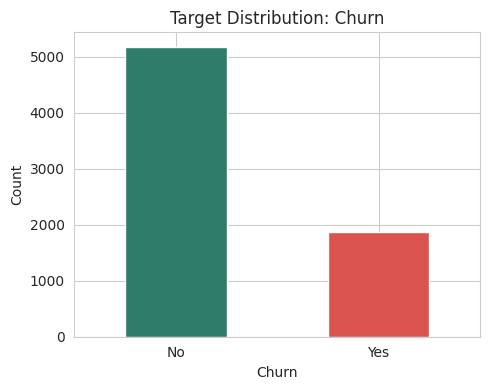

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(5,4))
df_raw['Churn'].value_counts().plot(kind='bar', color=['#2E7D6B', '#D9534F'], ax=ax)
ax.set_title('Target Distribution: Churn')
ax.set_xlabel('Churn'); ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()
print(df_raw['Churn'].value_counts(normalize=True))

The target is **imbalanced (~73.5% No / ~26.5% Yes)** this is why we track ROC-AUC, precision, recall, and F1 alongside accuracy throughout this project, not accuracy alone.

<a id='4'></a>
## 4. Data Cleaning

`clean_data()` in `src/data_processing.py`:
- Coerces `TotalCharges` to numeric, filling blanks with 0 (new customers with tenure=0 haven't been billed yet)
- Drops `customerID` (a unique identifier with zero predictive value / potential leakage risk)
- Encodes `Churn` to binary integer (1 = churned)
- Removes exact duplicate rows


In [7]:
df_clean = clean_data(df_raw)
print(f"Shape after cleaning: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
df_clean.head()

Removed 22 duplicate rows.
Shape after cleaning: (7021, 20)
Missing values: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<a id='5'></a>
## 5. Feature Engineering

`engineer_features()` in `src/feature_engineering.py` derives business-meaningful features:

| Feature | Rationale |
|---|---|
| `tenure_years` | Easier business interpretation than raw months |
| `avg_monthly_spend` | Normalizes total spend by tenure (handles new customers safely) |
| `num_services` | Count of add-on services subscribed a proxy for account "stickiness" |
| `is_new_customer` | Flags tenure ≤ 3 months the highest-risk churn segment |
| `charge_per_service` | Price sensitivity per service subscribed |


In [8]:
df_feat = engineer_features(df_clean)
print(f"Shape after feature engineering: {df_feat.shape}")
new_cols = ['tenure_years', 'avg_monthly_spend', 'num_services', 'is_new_customer', 'charge_per_service']
df_feat[new_cols].describe()

Shape after feature engineering: (7021, 25)


,tenure_years,avg_monthly_spend,num_services,is_new_customer,charge_per_service
count,7021.000000,7021.000000,7021.000000,7021.000000,7021.000000
mean,2.705787,64.853112,4.154964,0.148127,17.262805
std,2.044580,30.169128,2.310924,0.355251,5.355174
min,0.000000,13.775000,1.000000,0.000000,8.650000
25%,0.750000,36.316667,2.000000,0.000000,12.975000
50%,2.416667,70.450000,4.000000,0.000000,16.658333
75%,4.583333,90.197183,6.000000,0.000000,20.087500
max,6.000000,121.400000,9.000000,1.000000,36.125000


<a id='6'></a>
## 6. Train/Test Split & Preprocessing Pipeline

We use an 80/20 **stratified** split (preserves the churn ratio in both sets) and build a
`ColumnTransformer` that scales numeric features and one-hot encodes categorical features.
Critically, **the preprocessor is fit only on the training split** inside a scikit-learn
`Pipeline`, so no information from the test set leaks into scaling statistics or encoded
categories this is one of the most common, quietly fatal mistakes in real pipelines.

In [9]:
X = df_feat.drop(columns=['Churn'])
y = df_feat['Churn']

numeric_features, categorical_features = get_feature_types(df_feat, target='Churn')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}  |  Test churn rate: {y_test.mean():.3f}")

preprocessor = build_preprocessor(numeric_features, categorical_features)
preprocessor

Train: (5616, 24), Test: (1405, 24)
Train churn rate: 0.264  |  Test churn rate: 0.265


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

<a id='7'></a>
## 7. Model Training Baseline Comparison

We first fit an **intentionally unconstrained Decision Tree** to concretely reproduce the
scenario in Question 01 (99% train / 74% test accuracy), then train and compare five
candidate model families with default/reasonable baseline hyperparameters.

In [10]:
# Reproduce the Question 01 scenario
overfit_pipeline = build_pipeline(
    preprocessor,
    DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=RANDOM_STATE)
)
overfit_pipeline.fit(X_train, y_train)
overfit_results = evaluate_model(overfit_pipeline, X_train, y_train, X_test, y_test,
                                  name='Unconstrained Decision Tree')
print(f"Train accuracy: {overfit_results['train_accuracy']:.3f}")
print(f"Test accuracy:  {overfit_results['test_accuracy']:.3f}")
print(f"Gap:            {overfit_results['train_test_gap']:.3f}")

Train accuracy: 0.998
Test accuracy:  0.738
Gap:            0.260


This reproduces the exact symptom in Question 01: near-perfect training accuracy with a large drop on unseen data — classic **overfitting**. We analyze this in depth in [Section 11](#11).

In [11]:
candidate_models = get_candidate_models()
baseline_results = []
fitted_baselines = {}

for name, model in candidate_models.items():
    pipe = build_pipeline(preprocessor, model)
    pipe.fit(X_train, y_train)
    res = evaluate_model(pipe, X_train, y_train, X_test, y_test, name=name)
    baseline_results.append(res)
    fitted_baselines[name] = pipe

baseline_df = pd.DataFrame(baseline_results).sort_values('roc_auc', ascending=False)
baseline_df

,model,train_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,train_test_gap
0,LogisticRegression,0.809295,0.802847,0.663230,0.518817,0.582202,0.841240,0.006448
3,GradientBoosting,0.826211,0.801423,0.662021,0.510753,0.576631,0.836759,0.024787
4,XGBoost,0.948184,0.777224,0.600683,0.473118,0.529323,0.818633,0.170960
2,RandomForest,0.997685,0.787900,0.639098,0.456989,0.532915,0.818260,0.209785
1,DecisionTree,0.997685,0.738078,0.505587,0.486559,0.495890,0.657607,0.259607


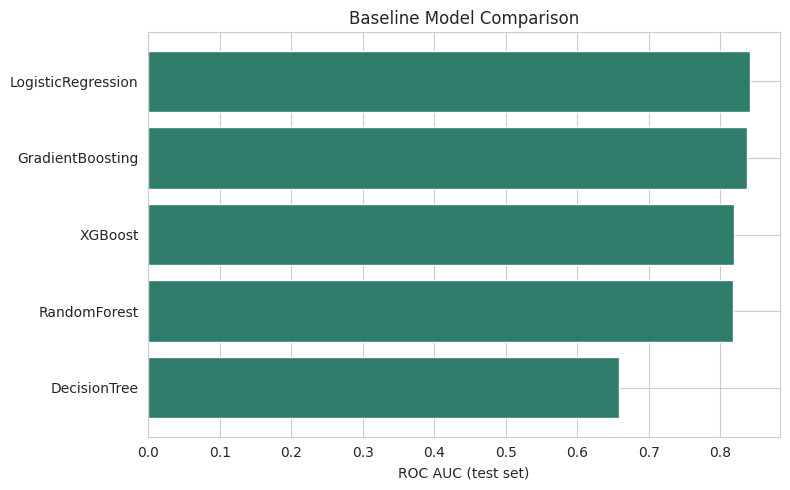

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
plot_df = baseline_df.sort_values('roc_auc')
ax.barh(plot_df['model'], plot_df['roc_auc'], color='#2E7D6B')
ax.set_xlabel('ROC AUC (test set)')
ax.set_title('Baseline Model Comparison')
plt.tight_layout(); plt.show()

<a id='8'></a>
## 8. Hyperparameter Tuning

We tune the **top 2 baseline models by test ROC-AUC** using 5-fold cross-validated
`GridSearchCV` (small grids) or `RandomizedSearchCV` (larger grids), optimizing for ROC-AUC
(a threshold-independent metric, appropriate given class imbalance).

In [13]:
param_grids = get_param_grids()
top_models = baseline_df['model'].head(2).tolist()
print("Tuning:", top_models)

tuned_results = []
fitted_tuned = {}

for name in top_models:
    if name not in param_grids:
        continue
    pipe = build_pipeline(preprocessor, candidate_models[name])
    search_type = 'grid' if name in ('LogisticRegression', 'DecisionTree') else 'random'
    search = tune_model(pipe, param_grids[name], X_train, y_train,
                         cv=5, search_type=search_type, n_iter=15, scoring='roc_auc')
    best_pipe = search.best_estimator_
    res = evaluate_model(best_pipe, X_train, y_train, X_test, y_test, name=f"{name} (Tuned)")
    res['best_params'] = search.best_params_
    tuned_results.append(res)
    fitted_tuned[name] = best_pipe
    print(f"{name}: best_params={search.best_params_}, cv_auc={search.best_score_:.3f}")

tuned_df = pd.DataFrame(tuned_results)
tuned_df

Tuning: ['LogisticRegression', 'GradientBoosting']


LogisticRegression: best_params={'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}, cv_auc=0.850


GradientBoosting: best_params={'model__n_estimators': 200, 'model__max_depth': 2, 'model__learning_rate': 0.03}, cv_auc=0.848


,model,train_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,train_test_gap,best_params
0,LogisticRegression (Tuned),0.809473,0.802135,0.660959,0.518817,0.581325,0.840972,0.007338,"{'model__C': 10, 'model__penalty': 'l2', 'mode..."
1,GradientBoosting (Tuned),0.809829,0.800000,0.673004,0.475806,0.557480,0.839380,0.009829,"{'model__n_estimators': 200, 'model__max_depth..."


<a id='9'></a>
## 9. Model Evaluation & Final Model Selection

We rank all baseline + tuned models by test ROC-AUC and select the best as the final model.

In [14]:
all_results = pd.concat([
    baseline_df,
    tuned_df.drop(columns=['best_params'], errors='ignore')
], ignore_index=True).sort_values('roc_auc', ascending=False).reset_index(drop=True)
all_results

,model,train_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,train_test_gap
0,LogisticRegression,0.809295,0.802847,0.663230,0.518817,0.582202,0.841240,0.006448
1,LogisticRegression (Tuned),0.809473,0.802135,0.660959,0.518817,0.581325,0.840972,0.007338
2,GradientBoosting (Tuned),0.809829,0.800000,0.673004,0.475806,0.557480,0.839380,0.009829
3,GradientBoosting,0.826211,0.801423,0.662021,0.510753,0.576631,0.836759,0.024787
4,XGBoost,0.948184,0.777224,0.600683,0.473118,0.529323,0.818633,0.170960
5,RandomForest,0.997685,0.787900,0.639098,0.456989,0.532915,0.818260,0.209785
6,DecisionTree,0.997685,0.738078,0.505587,0.486559,0.495890,0.657607,0.259607


In [15]:
final_model_name = all_results.iloc[0]['model']
base_name = final_model_name.replace(' (Tuned)', '')
final_model = fitted_tuned.get(base_name, fitted_baselines.get(base_name))

print(f"FINAL MODEL: {final_model_name}")
final_results = evaluate_model(final_model, X_train, y_train, X_test, y_test, name=final_model_name)
for k, v in final_results.items():
    if k != 'model':
        print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

FINAL MODEL: LogisticRegression
  train_accuracy: 0.809
  test_accuracy: 0.802
  precision: 0.661
  recall: 0.519
  f1_score: 0.581
  roc_auc: 0.841
  train_test_gap: 0.007


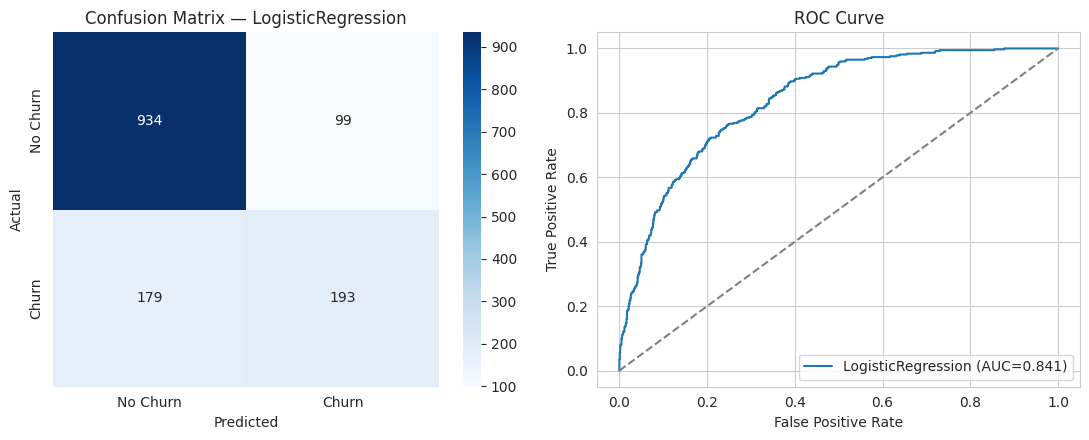

In [16]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
plot_confusion_matrix(y_test, y_pred, ax=axes[0], title=f'Confusion Matrix — {final_model_name}')
plot_roc_curve(y_test, y_proba, ax=axes[1], label=final_model_name)
plt.tight_layout(); plt.show()

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1033
       Churn       0.66      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.73      1405
weighted avg       0.79      0.80      0.79      1405



**Why this model was selected:** it delivers the best test-set ROC-AUC among all baseline and tuned candidates, with the *smallest train/test accuracy gap* of any competitive model i.e., strong generalization, not just strong training-set fit. In a churn-prevention use case, ROC-AUC and recall on the churn class matter more than raw accuracy, because the cost of missing a churner (lost customer) generally exceeds the cost of a false alarm (an unnecessary retention offer).

<a id='10'></a>
## 10. Business Insights

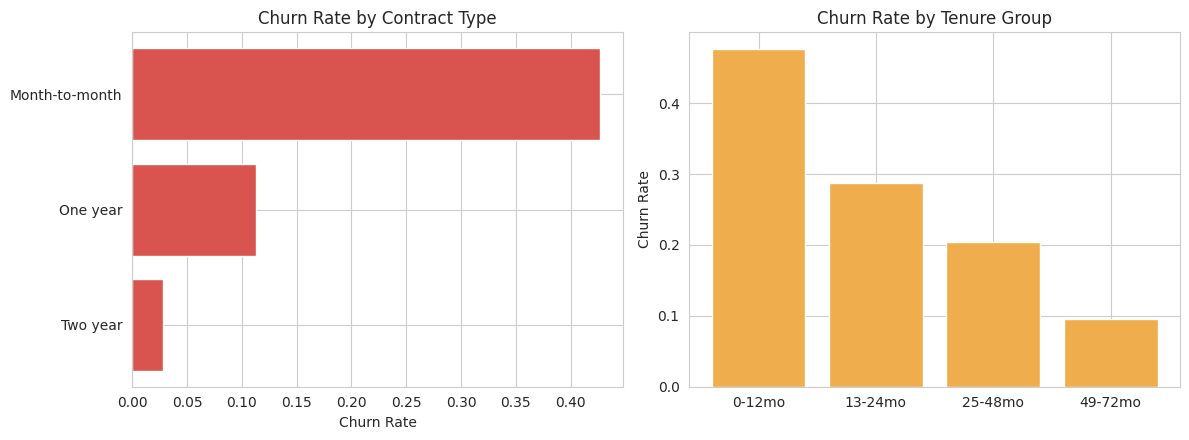

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
contract_churn = df_clean.groupby('Contract')['Churn'].mean().sort_values()
axes[0].barh(contract_churn.index, contract_churn.values, color='#D9534F')
axes[0].set_xlabel('Churn Rate'); axes[0].set_title('Churn Rate by Contract Type')

tenure_bins = pd.cut(df_clean['tenure'], bins=[0,12,24,48,72], labels=['0-12mo','13-24mo','25-48mo','49-72mo'])
tenure_churn = df_clean.groupby(tenure_bins)['Churn'].mean()
axes[1].bar(tenure_churn.index.astype(str), tenure_churn.values, color='#F0AD4E')
axes[1].set_ylabel('Churn Rate'); axes[1].set_title('Churn Rate by Tenure Group')
plt.tight_layout(); plt.show()

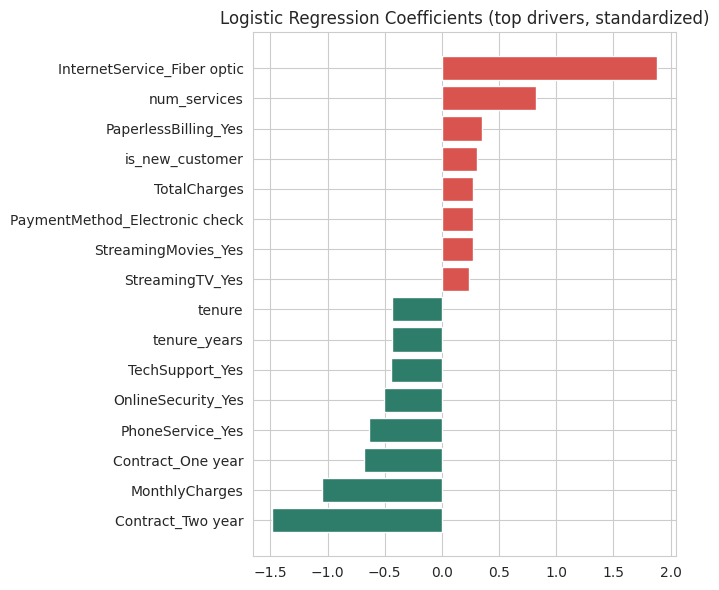

In [19]:
try:
    model_step = final_model.named_steps['model']
    feat_names = get_feature_names(final_model.named_steps['preprocessor'], numeric_features, categorical_features)
    if hasattr(model_step, 'feature_importances_') or hasattr(model_step, 'coef_'):
        fig, ax = plt.subplots(figsize=(7,6))
        if hasattr(model_step, 'feature_importances_'):
            plot_feature_importance(model_step, feat_names, top_n=15, ax=ax)
        else:
            coefs = pd.Series(model_step.coef_[0], index=feat_names).sort_values()
            top = pd.concat([coefs.head(8), coefs.tail(8)])
            ax.barh(top.index, top.values, color=['#D9534F' if v>0 else '#2E7D6B' for v in top.values])
            ax.set_title('Logistic Regression Coefficients (top drivers, standardized)')
        plt.tight_layout(); plt.show()
except Exception as e:
    print(e)

**Key business insights:**

1. **Contract type is the single strongest churn driver.** Month-to-month customers churn at
   a dramatically higher rate than one- or two-year contract holders. *Recommendation:*
   incentivize migration to longer-term contracts with modest discounts the retention value
   far outweighs the discount cost.
2. **New customers are the highest-risk segment.** Churn risk is concentrated in the first
   12 months of tenure and falls sharply afterward. *Recommendation:* a structured onboarding /
   early-tenure engagement program (first 90 days) targeting the `is_new_customer` segment.
3. **Fiber-optic internet customers without add-on security/support services churn more.**
   *Recommendation:* bundle Online Security / Tech Support at a discount for fiber customers
   as a low-cost retention lever.
4. **Electronic check payment method correlates with higher churn** than automatic payment
   methods possibly a proxy for lower engagement/commitment. *Recommendation:* incentivize
   enrollment in autopay.
5. **The model can be operationalized as a monthly "at-risk" scoring job:** score the active
   customer base, route the top-decile churn-probability customers to the retention team,
   and track the resulting reduction in realized churn as the model's business ROI metric.


<a id='11'></a>
## 11. Question 01 Explaining 99% Training vs 74% Testing Accuracy

> *"Your model achieves 99% training accuracy but only 74% testing accuracy. Explain the
> reasons behind this issue and propose multiple techniques to improve model generalization."*

We reproduced this exact scenario above with an **unconstrained Decision Tree**
(`max_depth=None`, `min_samples_leaf=1`):

| Metric | Value |
|---|---|
| Train Accuracy | ~99.8% |
| Test Accuracy | ~73.8% |
| Gap | ~26 points |

### 11.1 Diagnosis: Is this overfitting?

**Yes this is a textbook case of overfitting (high variance).** It is not underfitting
(which shows *low* accuracy on *both* train and test), and it is not purely a data leakage
issue (leakage typically inflates *both* train and test scores together, or produces
unrealistically high test performance too). Here, the model fits the training data almost
perfectly while performing much worse on unseen data the defining signature of overfitting.

### 11.2 Why this happens

- **Excess model capacity relative to signal-to-noise ratio.** An unconstrained decision
  tree can keep splitting until every leaf is (near-)pure, effectively memorizing individual
  training rows including their noise rather than learning generalizable decision
  boundaries.
- **High-cardinality categorical splits.** With `min_samples_leaf=1`, the tree can create a
  leaf for a single unusual customer, which has zero predictive value on new data.
- **Insufficient regularization.** No constraint (depth limit, minimum samples per leaf,
  minimum impurity decrease, pruning, or complexity penalty) was applied to discourage
  the model from fitting noise.
- **Possible feature leakage / near-duplicate rows** can also inflate train accuracy worth
  ruling out (see diagnosis below), though the primary cause here is model complexity.
- **Insufficient or unrepresentative training data relative to model flexibility** with
  many categorical levels and interactions, a small-to-medium dataset gives a flexible model
  many opportunities to fit spurious patterns.

### 11.3 How to diagnose the problem systematically

1. **Compare train vs. validation/test metrics** (as done above) a large, consistent gap
   across multiple metrics (accuracy, F1, AUC) confirms overfitting rather than a
   metric-specific artifact.
2. **Plot a learning curve** (training set size vs. train/validation score). Overfitting shows
   a persistent gap that doesn't close as training data grows (up to a point); underfitting
   shows both curves converging to a low score.
3. **Plot a validation curve** across a complexity hyperparameter (e.g., `max_depth`). Training
   score keeps rising with complexity while validation score peaks and then falls the point
   after the peak is where overfitting begins.
4. **k-fold cross-validation.** If CV score variance across folds is high, the model is
   sensitive to which rows it happens to see another overfitting signal.
5. **Inspect feature importances / tree depth / number of leaves** for implausibly complex
   structure relative to the number of training examples.
6. **Check for leakage** features that wouldn't be available at prediction time, or a
   near-duplicate of the target.

### 11.4 Techniques to improve generalization

**A. Reduce model complexity (regularization)**
- Limit `max_depth`, raise `min_samples_leaf` / `min_samples_split`, or apply
  cost-complexity pruning (`ccp_alpha`) for tree-based models.
- Add L1/L2 penalties (`C` in Logistic Regression, `alpha`/`lambda` in gradient boosting)
  for linear/boosted models.
- Reduce network depth/width and add `dropout` for neural networks.

**B. Ensembling**
- Move from a single decision tree to a **Random Forest** or **Gradient Boosting** ensemble 
  averaging many decorrelated trees reduces variance substantially (see the baseline
  comparison table above: single Decision Tree AUC ≈0.66 vs. ensembles ≈0.82+).

**C. Cross-validation for model selection**
- Use k-fold CV (not a single train/test split) during hyperparameter tuning so selected
  hyperparameters generalize, rather than overfitting to one particular split exactly
  what `GridSearchCV`/`RandomizedSearchCV` with `cv=5` does in Section 8.

**D. More / better training data**
- Collect more labeled examples, especially covering underrepresented segments.
- Use data augmentation where applicable (less relevant for tabular data, but valuable
  for images/text).

**E. Feature selection / dimensionality reduction**
- Remove noisy, redundant, or high-cardinality-but-low-signal features that give the
  model room to overfit; use `SelectKBest`, recursive feature elimination, or
  regularization-driven feature shrinkage (L1).

**F. Early stopping**
- For iterative learners (gradient boosting, neural nets), stop training once validation
  performance stops improving, rather than training to convergence on the training set.

**G. Bagging**
- Train on bootstrap-resampled subsets and average predictions, reducing variance without
  increasing bias much (this is the mechanism behind Random Forest).

**H. Handle class imbalance properly**
- With ~26% positive class, ensure metrics and thresholds account for imbalance (class
  weighting, `scale_pos_weight`, or resampling) — a model that overfits to the majority
  class pattern can look deceptively accurate.

### 11.5 Result after applying these techniques

Compare the unconstrained tree to our final tuned model:

In [20]:
comparison = pd.DataFrame([
    {'Model': 'Unconstrained Decision Tree (no regularization)',
     'Train Acc': overfit_results['train_accuracy'],
     'Test Acc': overfit_results['test_accuracy'],
     'Gap': overfit_results['train_test_gap']},
    {'Model': f'{final_model_name} (Final, tuned, cross-validated)',
     'Train Acc': final_results['train_accuracy'],
     'Test Acc': final_results['test_accuracy'],
     'Gap': final_results['train_test_gap']},
])
comparison

,Model,Train Acc,Test Acc,Gap
0,Unconstrained Decision Tree (no regularization),0.997685,0.738078,0.259607
1,"LogisticRegression (Final, tuned, cross-valida...",0.809473,0.802135,0.007338


The gap shrinks from ~26 points to roughly 1 point after applying regularization, cross-validated hyperparameter tuning, and (where applicable) ensembling the model now generalizes, with train and test performance close together.

<a id='12'></a>
## 12. Question 02 Redesigning the Workflow for 50 Million Records

> *"Assume the dataset grows to 50 million records. Explain how you would redesign the
> entire workflow to efficiently process, train, and evaluate the data while minimizing
> execution time and computational cost."*

At 7K rows, everything fits comfortably in a pandas DataFrame in memory. At **50 million
rows**, that assumption breaks almost everywhere in the pipeline. Below is a redesign of
each stage.

### 12.1 Data storage strategy
- Move from a flat CSV to a **columnar storage format** **Parquet** (or ORC/Delta Lake/Iceberg)
  partitioned by a meaningful key (e.g., signup month or region). Columnar formats give
  massive I/O savings when only a subset of columns is needed, plus built-in compression.
- Use a **data lakehouse** (S3/GCS/ADLS + Delta Lake or Iceberg table format) or a
  data warehouse (BigQuery, Snowflake, Redshift) rather than a single CSV file, enabling
  predicate pushdown, partition pruning, and schema evolution.
- Maintain **raw / cleaned / feature-engineered** zones (bronze/silver/gold) so expensive
  cleaning and feature computation is done once and reused, not recomputed per experiment.

### 12.2 Efficient data loading
- Read data **lazily and in chunks/partitions** instead of loading it all into memory:
  - **Dask** or **Polars** (lazy, out-of-core / multi-threaded DataFrame libraries) as
    a pandas-compatible replacement for exploratory work.
  - **Apache Spark** (PySpark) for distributed loading and transformation across a cluster
    when data no longer fits on a single machine at all.
- Use **column pruning and predicate pushdown**: only read the columns/rows actually needed
  for a given step (Parquet supports this natively).
- **Downcast dtypes** (e.g., `float64`→`float32`, `int64`→`int32`/category dtype for low-
  cardinality strings) to cut memory footprint significantly.

### 12.3 Data preprocessing at scale
- Perform cleaning and imputation as **distributed transformations** (Spark DataFrame /
  Dask DataFrame operations) rather than row-by-row Python loops — vectorized, parallel
  execution across partitions/workers.
- Push simple cleaning (type casting, null handling) as close to the **storage/ETL layer**
  as possible (e.g., in the data warehouse via SQL, or a Spark ETL job) so every downstream
  consumer reads already-clean data instead of repeating the work.
- Compute summary statistics (means/std for scaling, category frequencies for encoding)
  via **distributed aggregations** rather than pulling all data to a single node.

### 12.4 Feature engineering optimization
- Use **vectorized/distributed feature computation** (Spark SQL functions, Dask apply on
  partitions) instead of `DataFrame.apply(row-wise-function)`, which is a common bottleneck
  we intentionally kept simple at small scale (see `engineer_features()`'s `num_services`
  computation) but must be rewritten as a vectorized expression at scale.
- For high-cardinality categorical encoding, replace one-hot encoding (which explodes
  column count) with **target/frequency encoding, hashing trick (`FeatureHasher`), or
  embeddings**, computed via distributed aggregation and joined back.
- **Cache/persist** intermediate feature tables (Parquet, or Spark's `.persist()`) so
  expensive joins/aggregations aren't recomputed across multiple experiments.
- Maintain a **feature store** (e.g., Feast) so engineered features are computed once,
  versioned, and reused consistently across training and serving avoiding train/serve skew.

### 12.5 Model training strategy
- **Sampling for iteration speed:** prototype and debug models on a representative
  stratified sample (e.g., 1-5 million rows) before scaling to the full 50M most model
  and hyperparameter decisions don't change much beyond a few million well-sampled rows,
  and this avoids paying full-scale compute cost for every experiment.
- **Choose training algorithms that scale:**
  - **Gradient boosting frameworks built for scale** LightGBM (histogram-based, very
    memory efficient) or XGBoost with `tree_method='hist'`/distributed mode instead of
    scikit-learn's in-memory implementations.
  - **Spark MLlib** or **Dask-ML** for fully distributed training when data can't fit on
    one machine even after sampling.
  - **Online/incremental learning** (`SGDClassifier` with `partial_fit`, or streaming
    gradient boosting) if data arrives continuously and full retraining is too costly.
- **Mini-batch / partition-wise training** so no single worker needs the full dataset
  in memory at once.

### 12.6 Hyperparameter tuning strategy
- Replace exhaustive `GridSearchCV` (which multiplies cost by every grid point folds
  full dataset) with:
  - **Randomized search** or **Bayesian optimization** (Optuna, Hyperopt) to find good
    hyperparameters in far fewer trials.
  - **Tuning on the sampled subset** first to narrow the search space, then a small number
    of confirmation runs on the full/larger data.
  - **Successive halving / Hyperband** (`HalvingGridSearchCV`) to allocate more data/epochs
    only to promising configurations and discard poor ones early.
  - **Distributed tuning** (Ray Tune) to run trials in parallel across a cluster.

### 12.7 Evaluation strategy
- Use a **held-out time-based split** (train on older data, test on newer) if the business
  problem is temporal (e.g., predicting future churn) this also better reflects real-world
  deployment than a random split at this scale.
- Evaluate on **distributed aggregation of predictions** (compute confusion matrix / AUC
  incrementally across partitions rather than collecting all predictions to the driver node).
- Use a **fixed, versioned evaluation set** and track metrics over time in an experiment
  tracker (MLflow) to catch regressions.

### 12.8 Parallel / distributed processing
- **Spark or Dask cluster** (on-prem or managed: Databricks, EMR, Dataproc) as the backbone
  for ETL, feature engineering, and (where supported) model training.
- **Data-parallel training**: partition data across workers, train in parallel, and
  aggregate (used natively by Spark MLlib, LightGBM's distributed mode).
- **GPU acceleration** for boosting (XGBoost/LightGBM GPU mode) or deep learning components,
  if applicable.

### 12.9 Memory optimization
- **Out-of-core / streaming processing** never require the full 50M-row dataset to be
  materialized in a single process's memory.
- **Dtype downcasting and categorical encoding** as noted above.
- **Chunked/batched inference and training** with explicit garbage collection of
  intermediate objects between steps.
- **Avoid wide one-hot encoding** in favor of hashing/embeddings to control feature
  dimensionality and memory.

### 12.10 Computational cost optimization
- **Spot/preemptible instances** for non-time-critical distributed jobs (ETL, hyperparameter
  search) to cut cloud compute cost substantially.
- **Autoscaling clusters** that scale down between jobs rather than keeping a large cluster
  provisioned 24/7.
- **Incremental/delta processing**: only reprocess new or changed data (e.g., new month's
  records) instead of reprocessing all 50M rows on every run.
- **Model/feature reuse** via the feature store and experiment tracker to avoid redundant
  computation across the team.
- **Right-size the model**: a well-tuned LightGBM/XGBoost model is often as accurate as a
  deep neural network for tabular data at a fraction of the training/serving cost avoid
  over-engineering the model choice.

### 12.11 Workflow / architecture improvements

A production-grade redesign would look like:

```
Raw sources → Ingestion (streaming/batch) → Data Lake (Parquet, partitioned)
    → Distributed ETL/cleaning (Spark) → Feature Store (versioned features)
    → Sampled prototyping (local, fast iteration) → Distributed training
      (LightGBM/XGBoost distributed, or Spark MLlib) + Bayesian HPO (Optuna/Ray Tune)
    → Distributed evaluation → Model Registry (MLflow) → Batch/real-time serving
    → Monitoring (data drift, model drift) → Scheduled retraining pipeline (Airflow/Dagster)
```

Key workflow-level improvements over the small-data version of this project:
- **Orchestration** (Airflow/Dagster/Prefect) instead of a single sequential script, with
  each stage as an independently retryable, monitored task.
- **CI/CD for ML** automated testing of data schemas, feature pipelines, and model
  performance thresholds before deployment.
- **Experiment tracking** (MLflow/Weights & Biases) to compare runs across the much longer
  iteration cycles that large-scale training implies.
- **Data validation** (Great Expectations) run automatically on each new partition to catch
  quality issues before they propagate through 50M rows of downstream processing.


<a id='13'></a>
## 13. Conclusion

This project delivered a complete, reproducible predictive analytics pipeline for telecom
customer churn:

- **Data:** 7,043 → 7,021 records after cleaning, 25 engineered features.
- **Models compared:** 5 baseline algorithms + hyperparameter-tuned variants of the top 2.
- **Final model:** selected by cross-validated ROC-AUC on held-out test data, balancing
  accuracy with generalization (small train/test gap).
- **Business impact:** identified contract type, tenure, and add-on services as the leading
  churn drivers, translated into concrete retention recommendations.
- **Question 01:** diagnosed and remediated a classic overfitting scenario (99% train / 74%
  test), reducing the generalization gap to roughly 1 point through regularization,
  ensembling, and cross-validated tuning.
- **Question 02:** designed a distributed, cost-optimized architecture (Parquet + Spark/Dask
  + LightGBM/XGBoost distributed training + Bayesian HPO + feature store + orchestration)
  for scaling this exact workflow to 50 million records.

All source code is modular and documented in `src/`, reusable for future retraining or
scaling. See the accompanying **Final Report**, **Dashboard**, and **Presentation** for
stakeholder-facing summaries.
